In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import evaluate_checkpoint

sns.set_theme()

# ── Paths ──────────────────────────────────────────────────────────────────────
RUNS = {
    "Baseline Smaller": {
        "config": "results/baseline/best_config.json",
        "dataset": "dataset/test_dataset.pt",
        "checkpoint": "results/baseline/smaller_dataset/best_model.pt",
        "history": "results/baseline/smaller_dataset/best_model_history.csv",
    },
    "Seven Features": {
        "config": "results/7_features/best_config_7_features.json",
        "dataset": "dataset/7_features/test_dataset_7_features.pt",
        "checkpoint": "results/7_features/best_model.pt",
        "history": "results/7_features/best_model_history.csv",
    },
    "Baseline Larger": {
        "config": "results/baseline/best_config.json",
        "dataset": "dataset/test_dataset.pt",
        "checkpoint": "results/baseline/larger_dataset/best_model.pt",
        "history": "results/baseline/larger_dataset/best_model_history.csv",
    },
    "GPS": {
        "config": "results/gps/best_config_gps.json",
        "dataset": "dataset/test_dataset.pt",
        "checkpoint": "results/gps/best_model.pt",
        "history": "results/gps/best_model_history.csv",
    },
}

# Training Curves

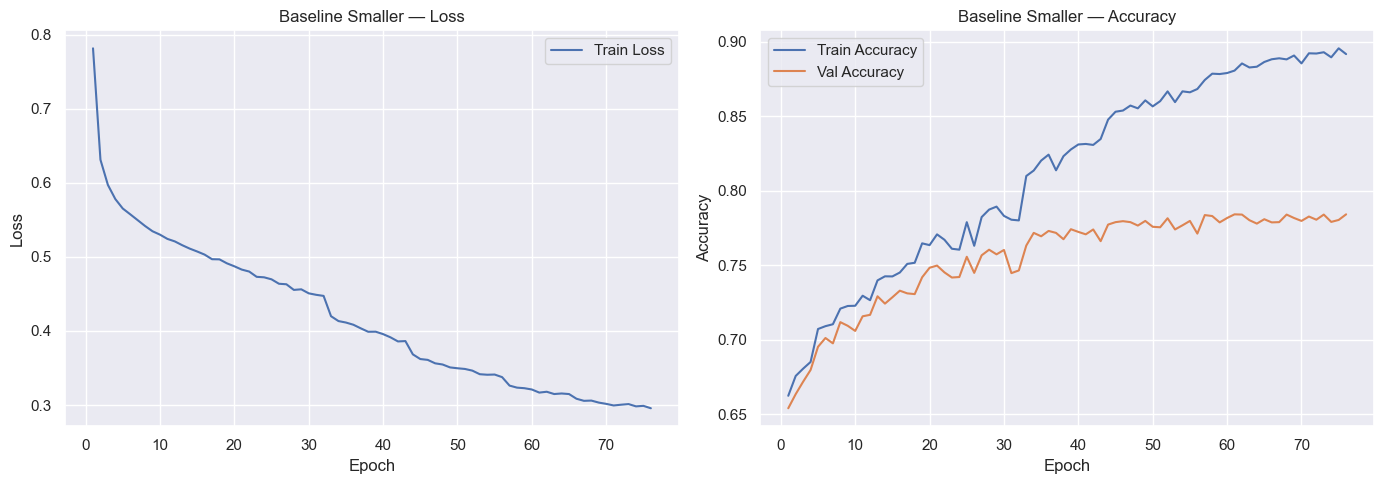

Baseline Smaller — Best epoch (highest val_acc): 61,  val_acc=0.7841



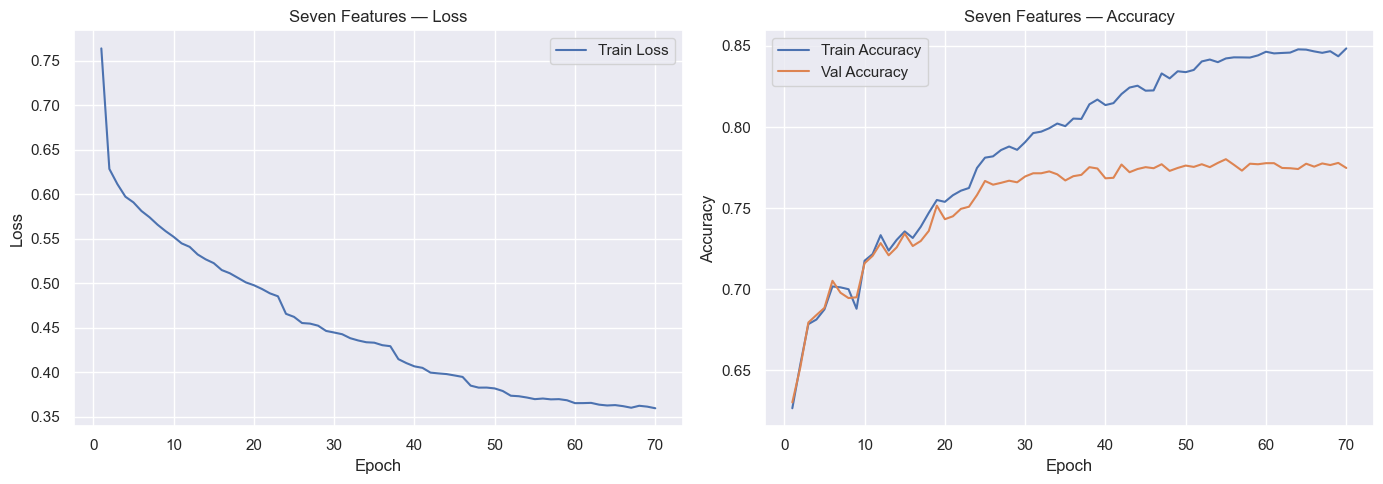

Seven Features — Best epoch (highest val_acc): 55,  val_acc=0.7802



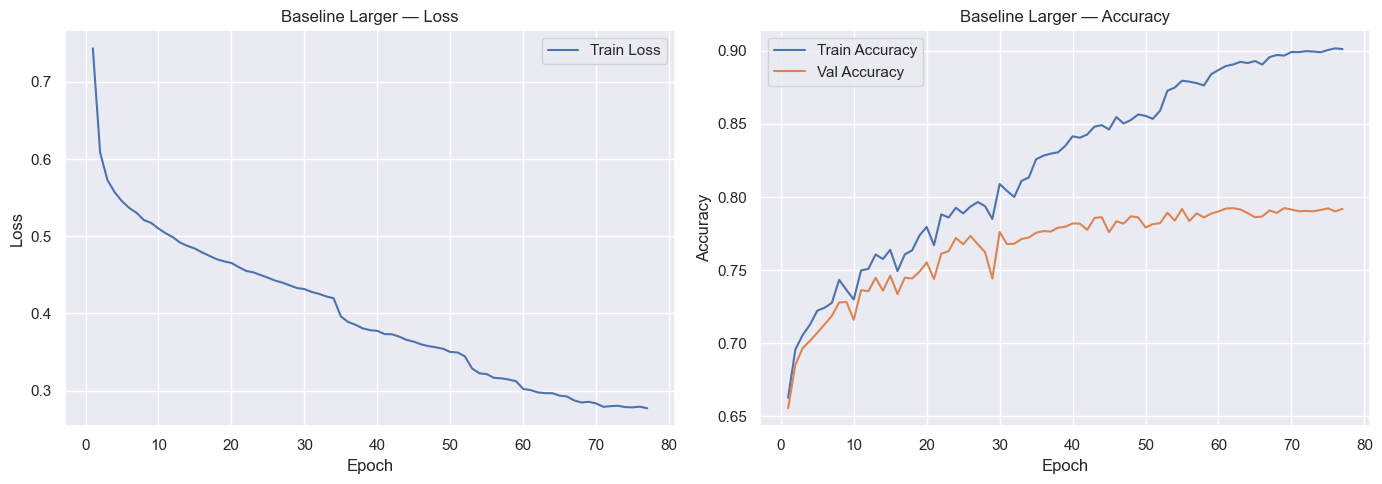

Baseline Larger — Best epoch (highest val_acc): 62,  val_acc=0.7924



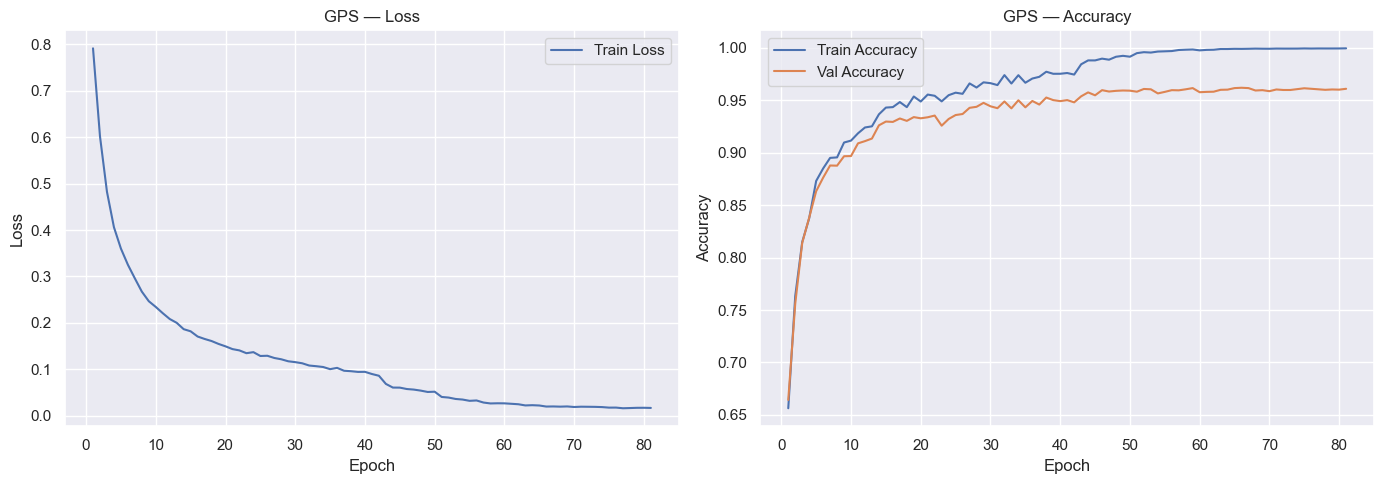

GPS — Best epoch (highest val_acc): 66,  val_acc=0.9620



In [2]:
for run_name, run_cfg in RUNS.items():
    history = pd.read_csv(run_cfg["history"])

    has_loss = "train_loss" in history.columns
    ncols = 2 if has_loss else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    if has_loss:
        sns.lineplot(data=history, x="epoch", y="train_loss", label="Train Loss", ax=axes[0])
        if "val_loss" in history.columns:
            sns.lineplot(data=history, x="epoch", y="val_loss", label="Val Loss", ax=axes[0])
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title(f"{run_name} — Loss")
        axes[0].legend()
        acc_ax = axes[1]
    else:
        acc_ax = axes[0]

    sns.lineplot(data=history, x="epoch", y="train_acc", label="Train Accuracy", ax=acc_ax)
    sns.lineplot(data=history, x="epoch", y="val_acc", label="Val Accuracy", ax=acc_ax)
    acc_ax.set_xlabel("Epoch")
    acc_ax.set_ylabel("Accuracy")
    acc_ax.set_title(f"{run_name} — Accuracy")
    acc_ax.legend()

    plt.tight_layout()
    plt.show()

    best_epoch = history.loc[history["val_acc"].idxmax()]
    print(f"{run_name} — Best epoch (highest val_acc): {int(best_epoch['epoch'])},  val_acc={best_epoch['val_acc']:.4f}")
    print()

In [3]:
model_results = {}
for run_name, run_cfg in RUNS.items():
    model_results[run_name] = evaluate_checkpoint(
        config_path=run_cfg["config"],
        dataset_path=run_cfg["dataset"],
        checkpoint_path=run_cfg["checkpoint"],
    )

In [4]:
model_comparison_df = pd.DataFrame(
    [
        {
            "Run": run_name,
            "Accuracy": run_results["accuracy"],
            "F1": run_results["f1"],
            "Examples": len(run_results["predictions_df"]),
        }
        for run_name, run_results in model_results.items()
    ]
)
model_comparison_df

,Run,Accuracy,F1,Examples
0,Baseline Smaller,0.762979,0.788537,6164
1,Seven Features,0.769468,0.789200,6164
2,Baseline Larger,0.780337,0.802854,6164
3,GPS,0.962524,0.964500,6164


In [5]:
selected_run_name = "Baseline Larger"
predictions_df = model_results[selected_run_name]["predictions_df"].copy()

avg_group_size_all = (
    predictions_df.groupby("num_nodes")["aut_grp_size"].mean().reset_index()
)

wrong_predictions_df = predictions_df[~predictions_df["correct"]]
avg_group_size_wrong = (
    wrong_predictions_df.groupby("num_nodes")["aut_grp_size"].mean().reset_index()
)

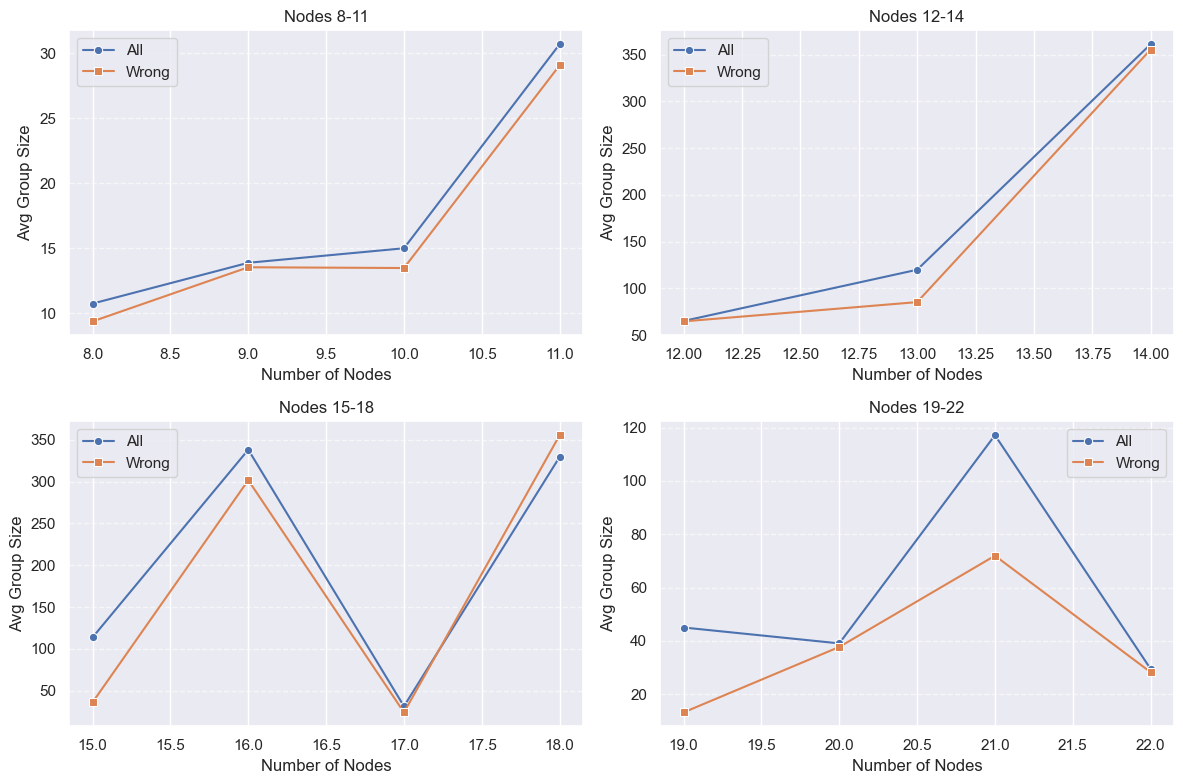

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ranges = [(8, 11), (12, 14), (15, 18), (19, 22)]
axes = axes.flatten()

for ax, (low, high) in zip(axes, ranges):
    mask_all = (avg_group_size_all["num_nodes"] >= low) & (
        avg_group_size_all["num_nodes"] <= high
    )

    mask_wrong = (avg_group_size_wrong["num_nodes"] >= low) & (
        avg_group_size_wrong["num_nodes"] <= high
    )

    sns.lineplot(
        data=avg_group_size_all[mask_all],
        x="num_nodes",
        y="aut_grp_size",
        marker="o",
        label="All",
        ax=ax,
    )

    sns.lineplot(
        data=avg_group_size_wrong[mask_wrong],
        x="num_nodes",
        y="aut_grp_size",
        marker="s",
        label="Wrong",
        ax=ax,
    )

    ax.set_title(f"Nodes {low}-{high}")
    ax.set_xlabel("Number of Nodes")
    ax.set_ylabel("Avg Group Size")
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()